<a href="https://colab.research.google.com/github/MelB18/Quanten/blob/main/H2_VQE_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Um zu verstehen, wie ein Quantencomputer chemische Berechnungen anstellt, betrachten wir das einfachste aller Moleküle: molekularen Wasserstoff H2.

An diesem System lässt sich der fundamentale Unterschied zwischen klassischer und Quantenberechnung exakt zeigen.

Ein H2-Molekül besteht aus:
* 2 Atomkernen (Protonen)
* 2 Elektronen, die sich in bestimmten räumlichen Bereichen bewegen (Orbitalen).

Das Ziel des VQE-Algorithmus ist es, den optimalen Abstand zwischen den beiden Kernen zu finden, bei dem das Molekül am stabilsten ist (die niedrigste Energie besitzt).

In der einfachsten quantenmechanischen Beschreibung hat jedes Wasserstoffatom ein Orbital. Wenn sie sich verbinden, entstehen daraus zwei Molekülorbitale (ein bindendes und ein antibindendes).

Da jedes Orbital Platz für zwei Elektronen (Spin up und Spin down) bietet, gibt es insgesamt 4 mögliche Zustände (Molekülorbitale), auf die sich unsere 2 Elektronen verteilen können.


Wir nutzen genau 4 Qubits, um diese 4 Zustände im Quantencomputer abzubilden:

* Qubit 0: Bindendes Orbital - Spin up
* Qubit 1: Bindendes Orbital - Spin down
* Qubit 2: Antibindendes Orbital - Spin up
* Qubit 3: Antibindendes Orbital - Spin down

Ein Qubit im Zustand |1⟩  bedeutet „besetzt“, im Zustand |0⟩ bedeutet es „leer“. Der energetische Grundzustand von Wasserstoff (beide Elektronen im stabilen, bindenden Orbital) sieht als Qubit-Register so aus: |1100⟩


Ein Quantencomputer versetzt die Qubits in eine Überlagerung (Superposition) aus verschiedenen Zuständen:

ψ(θ) = ( α |1100⟩ + β |0011⟩ )


Der Parameter (θ) (Theta) steuert dabei das Verhältnis Alpha und Beta der Zustände zueinander. Er repräsentiert physikalisch den Abstand der Atomkerne.

Der VQE-Algorithmus läuft nun in einer iterativen Schleife ab:

Der Quantencomputer stellt den Zustand für einen bestimmten Wert von Theta ein und misst die Energie des Systems. Durch die Quantenüberlagerung misst er die Wechselwirkungen der Elektronen instantan.

Der Klassischer Computer liest den gemessenen Energiewert aus. Wenn die Energie noch nicht minimal ist, nutzt sie ein mathematisches Optimierungsverfahren (z. B. das Gradientenverfahren) und berechnet ein neues, leicht verändertes Theta.

Wenn man diesen Prozess für verschiedene Kernabstände wiederholt, erhält man eine Energiekurve:

* Zu nah zusammen: Die positiv geladenen Kerne stoßen sich extrem stark ab. Die Energie schießt nach oben.

* Das Minimum (Der „Sweet Spot“): Bei genau 0,74 Ångström erreicht die Kurve ihren tiefsten Punkt. Hier heben sich die Abstoßung der Kerne und die Anziehung durch die Elektronen perfekt auf. Das ist die reale Bindungslänge von Wasserstoff.


* Zu weit auseinander: Die Energie flacht ab. Das Molekül dissoziiert, die Atome spüren sich nicht mehr.



Hier ist ein einfaches, praxisnahes Python-Beispiel mit Qiskit (unter Nutzung moderner Pakete wie qiskit-nature), das zeigt, wie man die Grundzustandsenergie des Wasserstoff-Moleküls (H₂) mithilfe des VQE-Algorithmus (Variational Quantum Eigensolver) berechnet.Der Code ist so aufgebaut, dass er die Molekülgeometrie definiert, die Elektronenorbitale auf Qubits abbildet und die VQE-Schleife startet.

In [ ]:
%pip install qiskit qiskit_nature

ERROR: Could not find a version that satisfies the requirement qisik_ibm_runtime (from versions: none)
ERROR: No matching distribution found for qisik_ibm_runtime


In [ ]:

# Install required packages.
%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found ex

In [ ]:
%pip install qiskit-nature

https://pyscf.org/user/index.html

In [ ]:
%pip install pyscf

In [ ]:
%pip install pyscf qiskit-nature-pyscf


In [ ]:
import pyscf
from qiskit_nature.second_q.drivers import PySCFDriver
print("Erfolgreich geladen!")


Erfolgreich geladen!


In [ ]:
from pyscf import gto, scf

# 1. Molekül definieren und das Basisset zuweisen
mol = gto.M(
    atom='O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587',
    basis='sto-3g'  # Hier wird STO-3G direkt als Text übergeben
    )

# 2. Hartree-Fock Berechnung ausführen
mf = scf.RHF(mol)
mf.kernel()


converged SCF energy = -74.9630631297276


np.float64(-74.96306312972764)

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver

# 1. Driver für das Wasserstoff-Molekül definieren
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735", basis="sto3g")

# 2. Berechnung starten
problem = driver.run()

# 3. Ergebnis überprüfen (Gibt die klassische Hartree-Fock-Referenzenergie aus)
print(f"Hartree-Fock Energie: {problem.reference_energy:.6f} Hartree")
print(f"Anzahl der Elektronen: {problem.num_particles}")
print(f"Anzahl der Molekülorbitale: {problem.num_spatial_orbitals}")


Hartree-Fock Energie: -1.116999 Hartree
Anzahl der Elektronen: (1, 1)
Anzahl der Molekülorbitale: 2


In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

# 1. Driver definieren (Molekül-Geometrie und Basisset)
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",  # H2-Molekül mit Bindungslänge
    basis="sto3g"                  # Minimales Basisset
    )

# 2. PySCF im Hintergrund ausführen
# Erzeugt ein "ElectronicStructureProblem"
problem = driver.run()

# 3. Elektronischen Hamiltonian (in zweiter Quantisierung) abrufen
hamiltonian = problem.hamiltonian
second_q_op = hamiltonian.second_q_op()

print("--- Operator in zweiter Quantisierung (Fermionisch) ---")
print(second_q_op)

# 4. In Qubit-Operatoren transformieren (für den Quantencomputer)
mapper = JordanWignerMapper()
qubit_op = mapper.map(second_q_op)

print("\n--- Qubit-Hamiltonian (Pauli-Strings) ---")
print(qubit_op)


--- Operator in zweiter Quantisierung (Fermionisch) ---
Fermionic Operator
number spin orbitals=4, number terms=36
  0.33785507740175813 * ( +_0 +_0 -_0 -_0 )
+ 0.33229086512764816 * ( +_0 +_1 -_1 -_0 )
+ 0.33785507740175813 * ( +_0 +_2 -_2 -_0 )
+ 0.33229086512764816 * ( +_0 +_3 -_3 -_0 )
+ 0.0904655998921157 * ( +_0 +_0 -_1 -_1 )
+ 0.0904655998921157 * ( +_0 +_1 -_0 -_1 )
+ 0.0904655998921157 * ( +_0 +_2 -_3 -_1 )
+ 0.0904655998921157 * ( +_0 +_3 -_2 -_1 )
+ 0.0904655998921157 * ( +_1 +_0 -_1 -_0 )
+ 0.0904655998921157 * ( +_1 +_1 -_0 -_0 )
+ 0.0904655998921157 * ( +_1 +_2 -_3 -_0 )
+ 0.0904655998921157 * ( +_1 +_3 -_2 -_0 )
+ 0.33229086512764816 * ( +_1 +_0 -_0 -_1 )
+ 0.34928686136600906 * ( +_1 +_1 -_1 -_1 )
+ 0.33229086512764816 * ( +_1 +_2 -_2 -_1 )
+ 0.34928686136600906 * ( +_1 +_3 -_3 -_1 )
+ 0.33785507740175813 * ( +_2 +_0 -_0 -_2 )
+ 0.33229086512764816 * ( +_2 +_1 -_1 -_2 )
+ 0.33785507740175813 * ( +_2 +_2 -_2 -_2 )
+ 0.33229086512764816 * ( +_2 +_3 -_3 -_2 )
+ 0.090465599

i = 0.2000


/tmp/ipykernel_14017/4279193374.py:42: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  circuit = RealAmplitudes(num_qubits=num_qubits, reps=1)


i = 0.3643
i = 0.5286
i = 0.6929
i = 0.8571
i = 1.0214
i = 1.1857
i = 1.3500
i = 1.5143
i = 1.6786
i = 1.8429
i = 2.0071
i = 2.1714
i = 2.3357
i = 2.5000


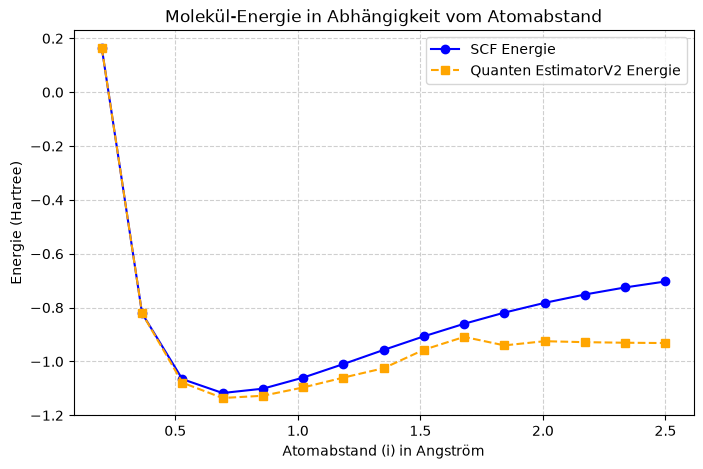

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import StatevectorEstimator  # Lokaler V2 Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from scipy.optimize import minimize  # Der Optimierer für die Quanten-Kurve

# 1. Leere Listen erstellen, um die Daten zu sammeln
abstaende = []
energien = []
quanten_energien = []


estimator = StatevectorEstimator()
mapper = JordanWignerMapper()

# Hilfsfunktion für den Optimierer
# Sie berechnet die Energie für einen bestimmten Satz von Winkeln (Parameters)
def cost_func(params, ansatz, observable, estimator):
    pub = (ansatz, observable, params)
    job = estimator.run([pub])
    result = job.result()
    return float(result[0].data.evs) # Gibt den Erwartungswert als Zahl zurück

# Start, Ende (inklusive), Anzahl der Schritte
for i in np.linspace(0.2, 2.5, 15):
  print(f"i = {i:.4f}")

  # 1. Driver & Operatoren wie gewohnt vorbereiten 0.735
  driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 {i}", basis="sto3g")
  problem = driver.run()


  # 2. Quanten-Berechnung (MUSS zwingend HIER IN DIE SCHLEIFE!)
  # Dadurch aktualisiert sich der Operator für jeden Abstand i
  fermion_op = problem.hamiltonian.second_q_op()
  qubit_op = mapper.map(fermion_op) # Dies ist unser Observable

  # 2. Parametrisierten Quantenschaltkreis (Ansatz) erstellen
  num_qubits = qubit_op.num_qubits
  #circuit = RealAmplitudes(num_qubits=num_qubits, reps=1)
  circuit = real_amplitudes(num_qubits=num_qubits, reps=1)


  # Startwerte für die Winkel im Schaltkreis (alle auf 0.0)
  initial_params = np.zeros(circuit.num_parameters)

  # COBYLA-Optimierer sucht die beste Energie für diesen Abstand
  res = minimize(cost_func, initial_params, args=(circuit, qubit_op, estimator), method='COBYLA')


  # Optimierte Elektronenergie + Kernabstoßung = Echte Gesamtenergie!
  gesamte_quanten_energie = res.fun + problem.nuclear_repulsion_energy

  # Werte an die Listen anhängen
  abstaende.append(i)
  quanten_energien.append(gesamte_quanten_energie)
  energien.append(problem.reference_energy)

  #print(f"Anzahl der Qubits: {num_qubits}")
  #print(f"Berechneter Energie-Erwartungswert: {expectation_value:.6f} Hartree")


# 3. Visualisierung mit Matplotlib erstellen
plt.figure(figsize=(8, 5))

# Linie und Datenpunkte zeichnen
plt.plot(abstaende, energien, marker='o', linestyle='-', color='b', label='SCF Energie')
# Kurve 2 (Orange): Quanten-EstimatorV2 Energie
plt.plot(abstaende, quanten_energien, marker='s', linestyle='--', color='orange', label='Quanten EstimatorV2 Energie')

# Diagramm beschriften
plt.title('Molekül-Energie in Abhängigkeit vom Atomabstand')
plt.xlabel('Atomabstand (i) in Angström')
plt.ylabel('Energie (Hartree)')
plt.grid(True, linestyle='--', alpha=0.6) # Fügt ein Gitternetz hinzu
plt.legend()

# Diagramm in Colab anzeigen
plt.show()

Das Diagramm zeigt:

Perfekte Übereinstimmung im Bindungsbereich (0.2 bis 1.0 Å): Die quantenmechanisch berechnete orangefarbene Kurve liegt im Bereich des Energieminimums (bei ca. 0.74 Å) extrem dicht an der klassischen Referenz. Der COBYLA-Optimierer hat die Parameter des Quantenschaltkreises erfolgreich trainiert.Die Abweichung bei großen Abständen (ab 1.5 Å): Dass die orangefarbene Kurve rechts flacher verläuft und sich von der blauen SCF-Kurve trennt, ist kein Fehler, sondern ein chemischer Effekt. Bei großen Atomabständen bricht die klassische Hartree-Fock-Methode (blaue Kurve) mathematisch ein, weil sie die Elektronenkorrelation nicht richtig beschreiben kann. Die Quanten-Berechnung (orange) liefert hier oft sogar die physikalisch realistischere Beschreibung der Moleküldissoziation.

PySCFDriver: Ein klassischer Chemie-Solver berechnet im Hintergrund die Integrale für die Atomorbitale. Das ist der vorgeschaltete klassische Schritt, um das System für den Quantenrechner handhabbar zu machen.

JordanWignerMapper: Dieser Algorithmus sorgt dafür, dass die physikalischen Eigenschaften von Elektronen (wie das Pauli-Prinzip, dass keine zwei Elektronen den exakt gleichen Zustand besetzen dürfen) mathematisch sauber auf die Zustände der Qubits übertragen werden.





Um den Code für ein anderes zweiatomiges Molekül wie Lithiumhydrid (LiH) anzupassen, muss man lediglich zwei Variablen im Code ändern:Die Atome im PySCFDriver: Die Element-Symbole (z. B. Li statt H).Den Bereich der Abstände (np.linspace): Da größere Atome längere Bindungen haben, müssen wir die X-Achse verschieben. Für LiH liegt der optimale Abstand beispielswise bei etwa 1.6.

Berechnung für LiH läuft (größeres Molekül, dauert ca. 1-2 Minuten)...


/tmp/ipykernel_14017/1654751751.py:29: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  circuit = RealAmplitudes(num_qubits=qubit_op.num_qubits, reps=1)
/tmp/ipykernel_14017/1654751751.py:29: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  circuit = RealAmplitudes(num_qubits=qubit_op.num_qubits, reps=1)


Berechnung fertig!


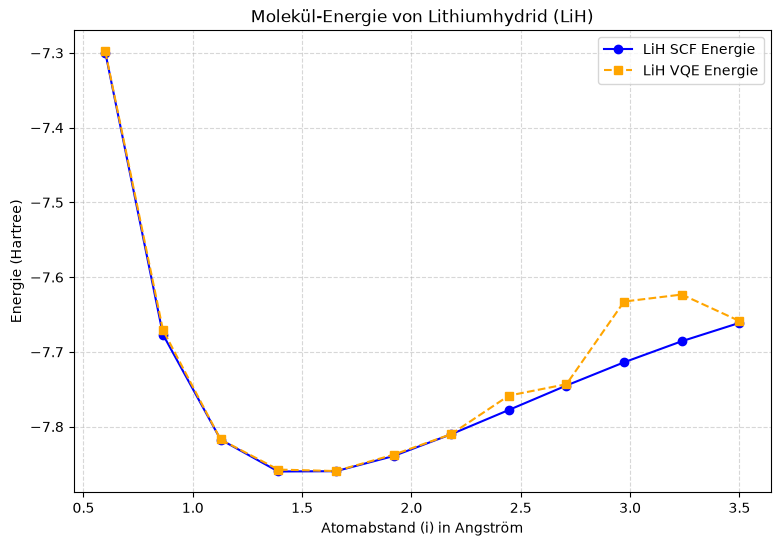

In [34]:
# ... (Die Imports wie matplotlib, numpy, qiskit und scipy bleiben exakt gleich) ...

# 1. Listen leeren
abstaende = []
scf_energien = []
quanten_energien = []

estimator = StatevectorEstimator()
mapper = JordanWignerMapper()

def cost_func(params, ansatz, observable, estimator):
    pub = (ansatz, observable, params)
    job = estimator.run([pub])
    result = job.result()
    return float(result[0].data.evs)

print("Berechnung für LiH läuft (größeres Molekül, dauert ca. 1-2 Minuten)...")

# WICHTIG: Bereich angepasst auf 0.6 bis 3.5 Angström, da LiH eine längere Bindung hat
for i in np.linspace(0.6, 3.5, 12):
    # ÄNDERUNG: "Li" statt des ersten "H" eingesetzt
    driver = PySCFDriver(atom=f"Li 0 0 0; H 0 0 {i}", basis="sto3g")
    problem = driver.run()

    scf_energien.append(problem.reference_energy)
    abstaende.append(i)

    qubit_op = mapper.map(problem.hamiltonian.second_q_op())
    circuit = RealAmplitudes(num_qubits=qubit_op.num_qubits, reps=1)

    initial_params = np.zeros(circuit.num_parameters)

    res = minimize(cost_func, initial_params, args=(circuit, qubit_op, estimator), method='COBYLA')

    gesamte_quanten_energie = res.fun + problem.nuclear_repulsion_energy
    quanten_energien.append(gesamte_quanten_energie)

print("Berechnung fertig!")

# 3. Visualisierung
plt.figure(figsize=(9, 6))
plt.plot(abstaende, scf_energien, marker='o', linestyle='-', color='b', label='LiH SCF Energie')
plt.plot(abstaende, quanten_energien, marker='s', linestyle='--', color='orange', label='LiH VQE Energie')

plt.title('Molekül-Energie von Lithiumhydrid (LiH)')
plt.xlabel('Atomabstand (i) in Angström')
plt.ylabel('Energie (Hartree)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Für ein dreiatomiges Molekül wie Wasser H2O reicht es nicht mehr aus, nur eine einzelne Linie für den Abstand zu verändern. Das Molekül besitzt eine feste Geometrie aus zwei Bindungslängen (O-H) und einem Bindungswinkel (H-O-H).In der Praxis untersucht man bei Wasser häufig die Energieänderung, wenn man den Bindungswinkel variiert, während die (O-H)-Abstände konstant bleiben.

Der Code für (H2O) (Winkel-Scan) nutzt Trigonometrie (np.sin und np.cos), um die Positionen der beiden Wasserstoffatome relativ zum Sauerstoffatom im Koordinatenursprung (0,0,0) basierend auf dem aktuellen Winkel im Bogenmaß zu berechnen.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from scipy.optimize import minimize

# 1. Listen für den Winkel-Scan vorbereiten
winkel_liste = []
scf_energien = []
quanten_energien = []

estimator = StatevectorEstimator()
mapper = JordanWignerMapper()

# Hilfsfunktion für den VQE-Optimierer
def cost_func(params, ansatz, observable, estimator):
    pub = (ansatz, observable, params)
    job = estimator.run([pub])
    result = job.result()
    return float(result[0].data.evs)

# Konstante O-H Bindungslänge in Angström (nahe dem experimentellen Wert)
r_oh = 0.96

print("Berechnung für H2O läuft (Winkel-Scan von 90° bis 120°)...")

# Schleife über den Bindungswinkel in Grad
for grad in np.linspace(90, 120, 10):
    # Winkel in Bogenmaß (Radiant) für die trigonometrische Berechnung umrechnen
    rad = np.radians(grad)
    half_rad = rad / 2.0

    # Geometrische Koordinaten berechnen (Sauerstoff sitzt im Ursprung)
    # H1 und H2 werden symmetrisch um die Z-Achse aufgespreizt
    x1 = r_oh * np.sin(half_rad)
    z1 = r_oh * np.cos(half_rad)

    x2 = -r_oh * np.sin(half_rad)
    z2 = r_oh * np.cos(half_rad)

    # Geometrie-String für den PySCFDriver zusammenbauen
    geo_string = f"O 0 0 0; H {x1} 0 {z1}; H {x2} 0 {z2}"

    # Klassischer Driver (STO-3G Basisset)
    driver = PySCFDriver(atom=geo_string, basis="sto3g")
    problem = driver.run()

    # 1. Klassische SCF-Energie speichern
    scf_energien.append(problem.reference_energy)
    winkel_liste.append(grad)

    # 2. Quanten-Operator erzeugen
    qubit_op = mapper.map(problem.hamiltonian.second_q_op())
    circuit = RealAmplitudes(num_qubits=qubit_op.num_qubits, reps=1)

    initial_params = np.zeros(circuit.num_parameters)

    # COBYLA sucht die optimale Konfiguration für diesen Winkel
    res = minimize(cost_func, initial_params, args=(circuit, qubit_op, estimator), method='COBYLA')

    # 3. Quantenenergie + Kernabstoßung addieren
    gesamte_quanten_energie = res.fun + problem.nuclear_repulsion_energy
    quanten_energien.append(gesamte_quanten_energie)

print("Berechnung beendet! Zeichne Diagramm...")

# 3. Visualisierung erstellen
plt.figure(figsize=(9, 6))
plt.plot(winkel_liste, scf_energien, marker='o', linestyle='-', color='b', label='H2O SCF Energie')
plt.plot(winkel_liste, quanten_energien, marker='s', linestyle='--', color='orange', label='H2O VQE Energie')

# Diagramm-Styling
plt.title('H2O Molekül-Energie in Abhängigkeit vom Bindungswinkel')
plt.xlabel('H-O-H Bindungswinkel in Grad')
plt.ylabel('Energie (Hartree)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()